# Derin Öğrenme Modelleriyle AAPL Getiri Tahmini

Bu notebook, AAPL hissesinin bir sonraki işlem günündeki log getirisini tahmin eden derin öğrenme modellerini karşılaştırır.


## 1. Kütüphaneler ve Ayarlar


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, LSTM, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Veri Yükleme


In [28]:
data = pd.read_csv("data/filled_aapl.csv", parse_dates=["Date"], index_col="Date")
data.index = pd.to_datetime(data.index, utc=True)
data = data.sort_index()

print(f"Veri boyutu: {data.shape}")
print(f"Tarih araligi: {data.index.min().date()} - {data.index.max().date()}")
display(data.head())


Veri boyutu: (11686, 7)
Tarih araligi: 1980-12-12 - 2025-09-26


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1980-12-12 05:00:00+00:00,0.098485,0.098913,0.098485,0.098485,469033600.0,0.0,0.0
1980-12-15 05:00:00+00:00,0.093775,0.093775,0.093347,0.093347,175884800.0,0.0,0.0
1980-12-16 05:00:00+00:00,0.086924,0.086924,0.086495,0.086495,105728000.0,0.0,0.0
1980-12-17 05:00:00+00:00,0.088636,0.089064,0.088636,0.088636,86441600.0,0.0,0.0
1980-12-18 05:00:00+00:00,0.091206,0.091634,0.091206,0.091206,73449600.0,0.0,0.0


## 3. Özellik Mühendisliği

Hedef değişken `target`, bir sonraki işlem gününün log getirisidir. Özellikler yalnızca tahmin anında bilinen bugünün ve geçmiş günlerin verileriyle oluşturulur.


In [29]:
df = data.copy()

df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df["hl_range"] = np.log(df["High"] / df["Low"])
df["oc_return"] = np.log(df["Close"] / df["Open"])
df["co_return"] = np.log(df["Open"] / df["Close"].shift(1))
df["volume_change"] = np.log(df["Volume"].replace(0, np.nan) / df["Volume"].replace(0, np.nan).shift(1))
df["dollar_volume"] = np.log((df["Close"] * df["Volume"]).replace(0, np.nan))

for lag in range(1, 16):
    df[f"log_return_lag{lag}"] = df["log_return"].shift(lag)

for window in [5, 10, 20, 60]:
    df[f"volatility_{window}"] = df["log_return"].rolling(window).std()
    df[f"momentum_{window}"] = df["log_return"].rolling(window).sum()
    df[f"mean_return_{window}"] = df["log_return"].rolling(window).mean()

delta = df["Close"].diff()
gain = delta.where(delta > 0, 0).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
df["RSI_14"] = 100 - (100 / (1 + gain / loss))

for window in [20, 60]:
    df[f"close_to_ma_{window}"] = np.log(df["Close"] / df["Close"].rolling(window).mean())

df["target"] = df["log_return"].shift(-1)

df = df.replace([np.inf, -np.inf], np.nan).dropna()

feature_cols = [
    col for col in df.columns
    if col not in data.columns and col not in ["log_return", "target"]
]

X = df[feature_cols]
y = df["target"]

print(f"Veri boyutu: {df.shape}")
print(f"X shape: {X.shape}")
print(f"Özellik sayisi: {len(feature_cols)}")


Veri boyutu: (10840, 44)
X shape: (10840, 35)
Özellik sayisi: 35


## 4. Zaman Bazlı Eğitim-Test Ayrımı

Verinin ilk %80'i eğitim, son %20'si test için ayrılır.


In [30]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx - 1], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx - 1], y.iloc[split_idx:]

print(f"Egitim seti: {X_train.shape[0]} gozlem ({X_train.index.min().date()} - {X_train.index.max().date()})")
print(f"Test seti: {X_test.shape[0]} gozlem ({X_test.index.min().date()} - {X_test.index.max().date()})")


Egitim seti: 8671 gozlem (1981-03-06 - 2016-10-05)
Test seti: 2168 gozlem (2016-10-07 - 2025-09-25)


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Model Performans Degerlendirme Fonksiyonu

In [6]:
def evaluate_model(y_true, y_pred, model_name):
    """Model performansini degerlendir ve gorsellestir."""
    
    y_true_arr = y_true.values if hasattr(y_true, "values") else y_true
    
    # Temel metrikler
    mse = mean_squared_error(y_true_arr, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_arr, y_pred)
    
    print(f"\n{model_name} - Test Performansi")
    print("-" * 50)
    print(f"MSE:  {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE:  {mae:.6f}")
    
    # Gorsellestirme
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Gercek vs Tahmin scatter
    axes[0].scatter(y_true_arr, y_pred, alpha=0.3, s=10)
    min_val, max_val = y_true_arr.min(), y_true_arr.max()
    axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
    axes[0].set_xlabel("Gercek Deger")
    axes[0].set_ylabel("Tahmin")
    axes[0].set_title(f"{model_name}\nGercek vs Tahmin")
    axes[0].grid(alpha=0.3)
    
    # Zaman serisi
    n_show = min(200, len(y_true_arr))
    axes[1].plot(range(n_show), y_true_arr[:n_show], label="Gercek", alpha=0.7)
    axes[1].plot(range(n_show), y_pred[:n_show], label="Tahmin", alpha=0.7)
    axes[1].set_xlabel("Gozlem")
    axes[1].set_ylabel("Log Getiri")
    axes[1].set_title(f"{model_name}\nZaman Serisi (Ilk {n_show})")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Hata dagilimi
    errors = y_true_arr - y_pred
    axes[2].hist(errors, bins=50, edgecolor="white", alpha=0.7)
    axes[2].axvline(0, color="red", linestyle="--", linewidth=2)
    axes[2].axvline(np.mean(errors), color="blue", linestyle="-", linewidth=2, 
                    label=f"Ort: {np.mean(errors):.5f}")
    axes[2].set_xlabel("Hata")
    axes[2].set_ylabel("Frekans")
    axes[2].set_title(f"{model_name}\nHata Dagilimi")
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {"MSE": mse, "RMSE": rmse, "MAE": mae}

## 5. CNN (Convolutional Neural Network)

Konvolusyonel sinir agi, zaman serilerinde yerel desenleri yakalamak icin kullanilir. 1 boyutlu konvolusyon katmanlari, ardisik veri noktalarindaki oruntuleri ogrenir.

**Model Mimarisi:**
- 2 adet Conv1D katmani (64 ve 32 filtre)
- Flatten katmani
- Dense katmanlar (50 noron)
- Dropout regularizasyonu (%20)

In [32]:
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(time_steps, len(X)):
        Xs.append(X[i - time_steps:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

SEQUENCE_LENGTH = 60

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, SEQUENCE_LENGTH)
X_test_context = np.concatenate([X_train_scaled[-SEQUENCE_LENGTH:], X_test_scaled])
y_test_context = np.concatenate([y_train.values[-SEQUENCE_LENGTH:], y_test.values])
X_test_seq, y_test_seq = create_sequences(X_test_context, y_test_context, SEQUENCE_LENGTH)

validation_size = int(len(X_train_seq) * 0.2)
X_fit_seq, X_val_seq = X_train_seq[:-validation_size], X_train_seq[-validation_size:]
y_fit_seq, y_val_seq = y_train_seq[:-validation_size], y_train_seq[-validation_size:]

X_train_cnn, y_train_cnn = X_train_seq, y_train_seq
X_test_cnn, y_test_cnn = X_test_seq, y_test_seq

print(f"CNN veri sekli:")
print(f"X_train_cnn: {X_train_cnn.shape}")
print(f"X_test_cnn: {X_test_cnn.shape}")

CNN veri sekli:
X_train_cnn: (8611, 60, 35)
X_test_cnn: (2168, 60, 35)


In [33]:
# CNN Model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])),
    Conv1D(filters=32, kernel_size=2, activation='relu'),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
], name='CNN_Log_Returns')

cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
cnn_model.summary()

Model: "CNN_Log_Returns"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 59, 64)         │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 58, 32)         │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │        92,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,573 (396.77 KB)

 Trainable params: 101,573 (396.77 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# CNN Egitimi
early_stop_cnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn = cnn_model.fit(
    X_fit_seq, y_fit_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop_cnn],
    verbose=1
)

Epoch 1/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0295 - mae: 0.0594 - val_loss: 3.2238e-04 - val_mae: 0.0128
Epoch 2/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0012 - mae: 0.0231 - val_loss: 2.8280e-04 - val_mae: 0.0119
Epoch 3/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010 - mae: 0.0220 - val_loss: 2.7704e-04 - val_mae: 0.0118
Epoch 4/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010 - mae: 0.0218 - val_loss: 2.7575e-04 - val_mae: 0.0118
Epoch 5/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010 - mae: 0.0218 - val_loss: 2.7546e-04 - val_mae: 0.0118
Epoch 6/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010 - mae: 0.0217 - val_loss: 2.7450e-04 - val_mae: 0.0118
Epoch 7/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010 - mae: 0.0216 - val_loss: 2.7469e-04 - val_mae: 0.0118
Epoch 8/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010 - mae: 0.0216 - val_loss: 2.7491e-04 - val_mae: 0.0118
Epoch 9/50
216/216 ━━━━━

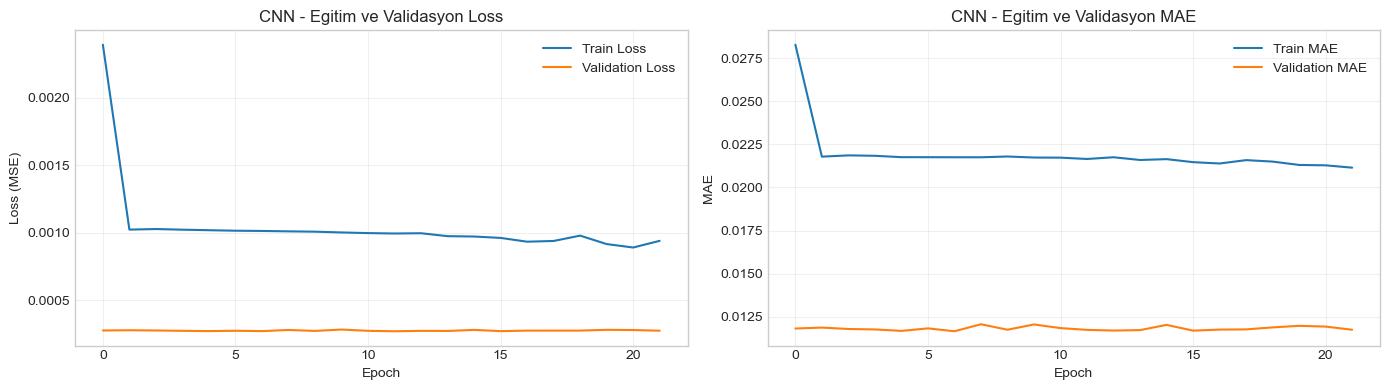

In [10]:
# CNN Egitim grafigi
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_cnn.history['loss'], label='Train Loss')
axes[0].plot(history_cnn.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('CNN - Egitim ve Validasyon Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_cnn.history['mae'], label='Train MAE')
axes[1].plot(history_cnn.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('CNN - Egitim ve Validasyon MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


CNN - Test Performansi
--------------------------------------------------
MSE:  0.000335
RMSE: 0.018315
MAE:  0.012380


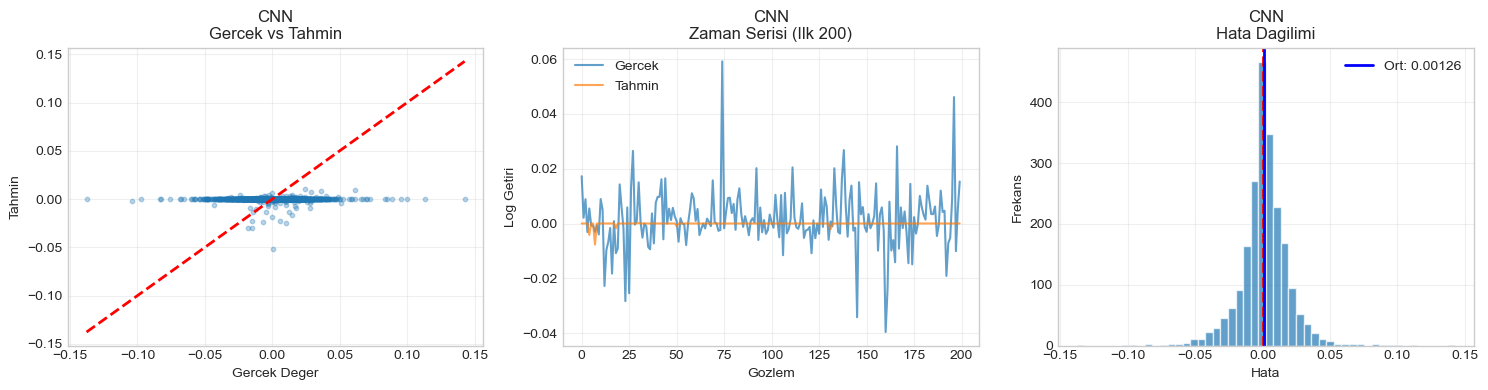

In [35]:
# CNN Tahmin ve Degerlendirme
y_pred_cnn = cnn_model.predict(X_test_cnn, verbose=0).flatten()
cnn_results = evaluate_model(y_test_cnn, y_pred_cnn, 'CNN')

In [45]:
# CNN Modelini Kaydet
import os
os.makedirs('saved_models', exist_ok=True)
cnn_model.save('saved_models/cnn_log_returns_model.keras')

## 6. LSTM (Long Short-Term Memory)

Uzun Kisa Sureli Bellek agi, zaman serilerinde uzun vadeli bagimliliklari ogrenen tekrarlayan sinir agi turudur. Gate mekanizmasi sayesinde bilgiyi uzun sure koruyabilir.

**Model Mimarisi:**
- 2 katmanli LSTM (100 ve 50 unit)
- BatchNormalization
- Dropout regularizasyonu (%30)
- Dense katmanlar (50, 25 noron)
- Sequence uzunlugu: 60 gun

In [36]:
def create_sequences(X, y, time_steps):

    Xs, ys = [], []
    for i in range(time_steps, len(X)):
        Xs.append(X[i - time_steps:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

SEQUENCE_LENGTH = 60

X_train_lstm, y_train_lstm = X_train_seq, y_train_seq
X_test_lstm, y_test_lstm = X_test_seq, y_test_seq

print(f"LSTM veri sekli:")
print(f"X_train_lstm: {X_train_lstm.shape}")
print(f"X_test_lstm: {X_test_lstm.shape}")

LSTM veri sekli:
X_train_lstm: (8611, 60, 35)
X_test_lstm: (2168, 60, 35)


In [37]:
# LSTM Model
lstm_model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_lstm.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(50, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
], name='LSTM_Log_Returns')

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(f"LSTM Model - Toplam parametre: {lstm_model.count_params():,}")
lstm_model.summary()

LSTM Model - Toplam parametre: 89,051


Model: "LSTM_Log_Returns"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 60, 100)        │        54,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,051 (347.86 KB)

 Trainable params: 88,751 (346.68 KB)

 Non-trainable params: 300 (1.17 KB)

In [38]:
# LSTM Egitimi
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_lstm = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

history_lstm = lstm_model.fit(
    X_fit_seq, y_fit_seq,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop_lstm, reduce_lr_lstm],
    verbose=1
)

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - loss: 0.1780 - mae: 0.2993 - val_loss: 0.0024 - val_mae: 0.0384 - learning_rate: 0.0010
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0317 - mae: 0.1359 - val_loss: 0.0011 - val_mae: 0.0252 - learning_rate: 0.0010
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0158 - mae: 0.0964 - val_loss: 0.0010 - val_mae: 0.0246 - learning_rate: 0.0010
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - loss: 0.0098 - mae: 0.0748 - val_loss: 0.0011 - val_mae: 0.0251 - learning_rate: 0.0010
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.0068 - mae: 0.0625 - val_loss: 9.0044e-04 - val_mae: 0.0234 - learning_rate: 0.0010
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 0.0052 - mae: 0.0544 - val_loss: 9.5699e-04 - val_mae: 0.0254 - learning_rate: 0.0010
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 0.0039 - mae: 0.0467 - val_loss: 6.0932e-04 - val_mae: 0.0190 - l

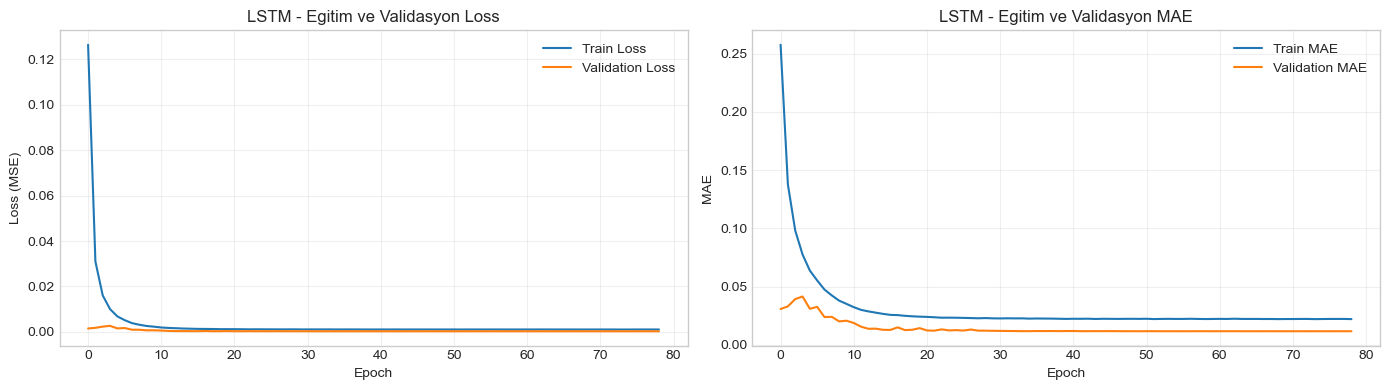

In [16]:
# LSTM Egitim grafigi
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_lstm.history['loss'], label='Train Loss')
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('LSTM - Egitim ve Validasyon Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_lstm.history['mae'], label='Train MAE')
axes[1].plot(history_lstm.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('LSTM - Egitim ve Validasyon MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


LSTM - Test Performansi
--------------------------------------------------
MSE:  0.000334
RMSE: 0.018262
MAE:  0.012333


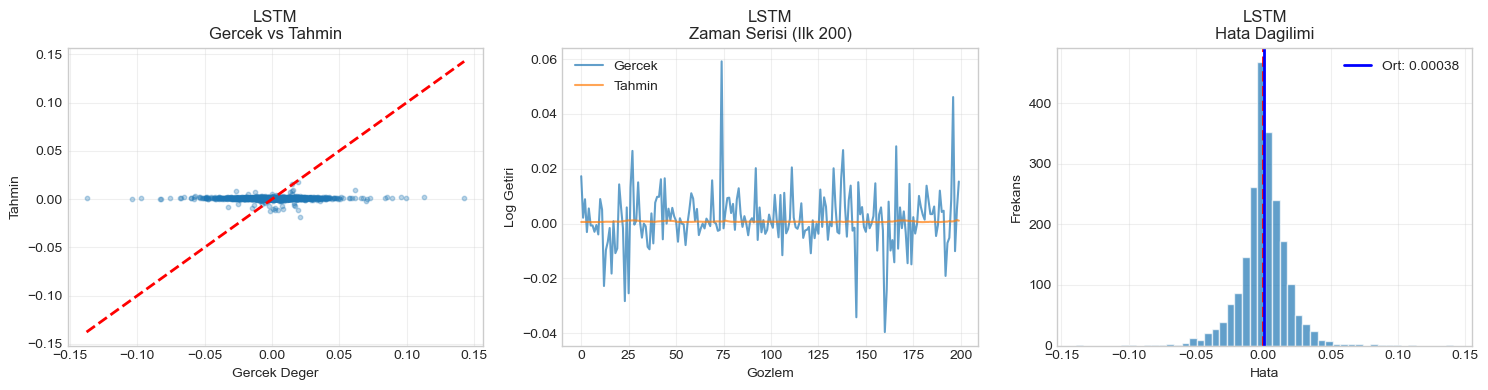

In [39]:
# LSTM Tahmin ve Degerlendirme
y_pred_lstm = lstm_model.predict(X_test_lstm, verbose=0).flatten()
y_test_lstm_series = pd.Series(y_test_seq, name='target')
lstm_results = evaluate_model(y_test_lstm_series, y_pred_lstm, 'LSTM')

In [46]:
# LSTM Modelini Kaydet
import os
os.makedirs('saved_models', exist_ok=True)
lstm_model.save('saved_models/lstm_log_returns_model.keras')

## 7. BiLSTM (Bidirectional Long Short-Term Memory)

Cift yonlu LSTM, zaman serilerini hem ileri hem geri yonde isleyerek daha zengin ozellik cikarimi saglar. Her iki yondeki baglam bilgisini kullanir.

**Model Mimarisi:**
- 3 katmanli BiLSTM (128, 64, 32 unit)
- L2 regularizasyonu
- BatchNormalization
- Dropout regularizasyonu (%20)
- Dense katmanlar (64, 32, 16 noron)

In [40]:
# BiLSTM icin ayni sequence verilerini kullan
X_train_bilstm = X_train_lstm.copy()
X_test_bilstm = X_test_lstm.copy()
y_train_bilstm = y_train_lstm.copy()
y_test_bilstm = y_test_lstm.copy()

print(f"BiLSTM veri sekli:")
print(f"X_train_bilstm: {X_train_bilstm.shape}")
print(f"X_test_bilstm: {X_test_bilstm.shape}")

BiLSTM veri sekli:
X_train_bilstm: (8611, 60, 35)
X_test_bilstm: (2168, 60, 35)


In [41]:
# BiLSTM Model
bilstm_model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True, 
                       kernel_regularizer=l2(0.001),
                       recurrent_regularizer=l2(0.001)), 
                  input_shape=(SEQUENCE_LENGTH, X_train_bilstm.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    
    Bidirectional(LSTM(64, return_sequences=True,
                       kernel_regularizer=l2(0.001),
                       recurrent_regularizer=l2(0.001))),
    BatchNormalization(),
    Dropout(0.2),
    
    Bidirectional(LSTM(32, return_sequences=False,
                       kernel_regularizer=l2(0.001),
                       recurrent_regularizer=l2(0.001))),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.15),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(16, activation='relu'),
    Dense(1)
], name='BiLSTM_Log_Returns')

bilstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

print(f"BiLSTM Model - Toplam parametre: {bilstm_model.count_params():,}")
bilstm_model.summary()

BiLSTM Model - Toplam parametre: 382,081


Model: "BiLSTM_Log_Returns"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 60, 256)        │       167,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 60, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 60, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 382,081 (1.46 MB)

 Trainable params: 381,185 (1.45 MB)

 Non-trainable params: 896 (3.50 KB)

In [42]:
# BiLSTM Egitimi
early_stop_bilstm = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
reduce_lr_bilstm = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-7)

history_bilstm = bilstm_model.fit(
    X_fit_seq, y_fit_seq,
    epochs=150,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop_bilstm, reduce_lr_bilstm],
    verbose=1
)

Epoch 1/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 32s 100ms/step - loss: 1.2738 - mae: 0.1159 - val_loss: 1.0056 - val_mae: 0.0232 - learning_rate: 5.0000e-04
Epoch 2/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.8122 - mae: 0.0476 - val_loss: 0.6364 - val_mae: 0.0190 - learning_rate: 5.0000e-04
Epoch 3/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.5134 - mae: 0.0313 - val_loss: 0.4045 - val_mae: 0.0155 - learning_rate: 5.0000e-04
Epoch 4/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.3288 - mae: 0.0256 - val_loss: 0.2618 - val_mae: 0.0134 - learning_rate: 5.0000e-04
Epoch 5/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.2154 - mae: 0.0234 - val_loss: 0.1735 - val_mae: 0.0125 - learning_rate: 5.0000e-04
Epoch 6/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.1443 - mae: 0.0226 - val_loss: 0.1170 - val_mae: 0.0119 - learning_rate: 5.0000e-04
Epoch 7/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - loss: 0.0979 - mae: 0.0222 - val_loss: 0.0794 - 

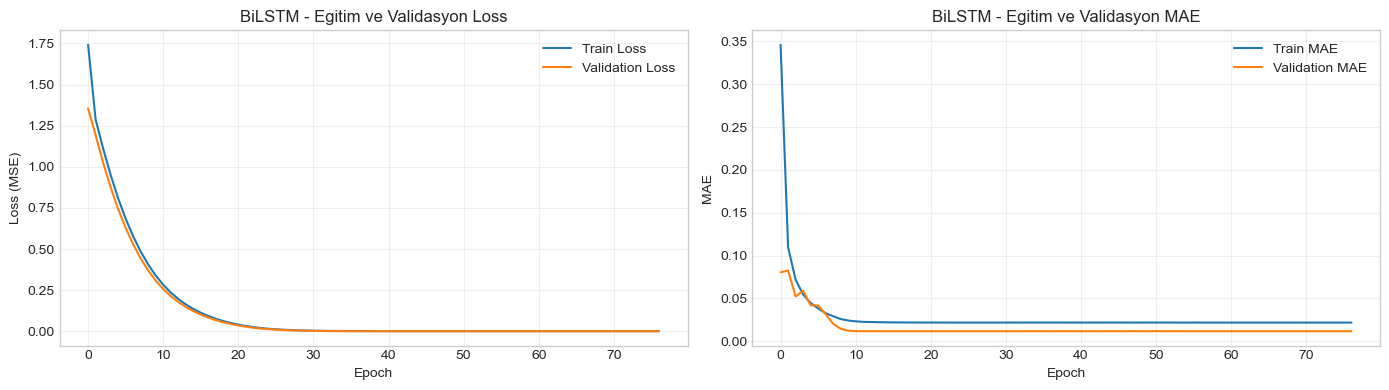

In [22]:
# BiLSTM Egitim grafigi
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_bilstm.history['loss'], label='Train Loss')
axes[0].plot(history_bilstm.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('BiLSTM - Egitim ve Validasyon Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_bilstm.history['mae'], label='Train MAE')
axes[1].plot(history_bilstm.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('BiLSTM - Egitim ve Validasyon MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


BiLSTM - Test Performansi
--------------------------------------------------
MSE:  0.000332
RMSE: 0.018229
MAE:  0.012305


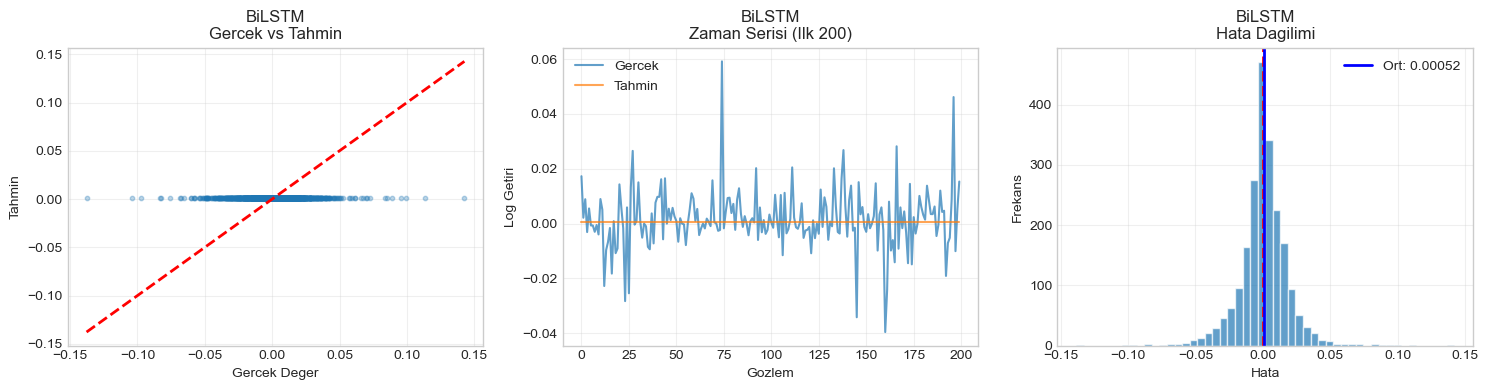

In [43]:
# BiLSTM Tahmin ve Degerlendirme
y_pred_bilstm = bilstm_model.predict(X_test_bilstm, verbose=0).flatten()
y_test_bilstm_series = pd.Series(y_test_seq, name='target')
bilstm_results = evaluate_model(y_test_bilstm_series, y_pred_bilstm, 'BiLSTM')

In [47]:
# BiLSTM Modelini Kaydet
bilstm_model.save('saved_models/bilstm_log_returns_model.keras')

## 8. Model Karsilastirmasi

In [44]:
# Sonuclari birlestir
results_summary = pd.DataFrame({
    'Model': ['CNN', 'LSTM', 'BiLSTM'],
    'MSE': [cnn_results['MSE'], lstm_results['MSE'], bilstm_results['MSE']],
    'RMSE': [cnn_results['RMSE'], lstm_results['RMSE'], bilstm_results['RMSE']],
    'MAE': [cnn_results['MAE'], lstm_results['MAE'], bilstm_results['MAE']]
})

results_summary = results_summary.sort_values('RMSE')

print("Derin Ogrenme Modelleri Karsilastirmasi")
print("=" * 60)
print(results_summary.to_string(index=False))
print("=" * 60)
print(f"\nEn iyi model (RMSE bazli): {results_summary.iloc[0]['Model']}")

Derin Ogrenme Modelleri Karsilastirmasi
 Model      MSE     RMSE      MAE
BiLSTM 0.000332 0.018229 0.012305
  LSTM 0.000334 0.018262 0.012333
   CNN 0.000335 0.018315 0.012380

En iyi model (RMSE bazli): BiLSTM


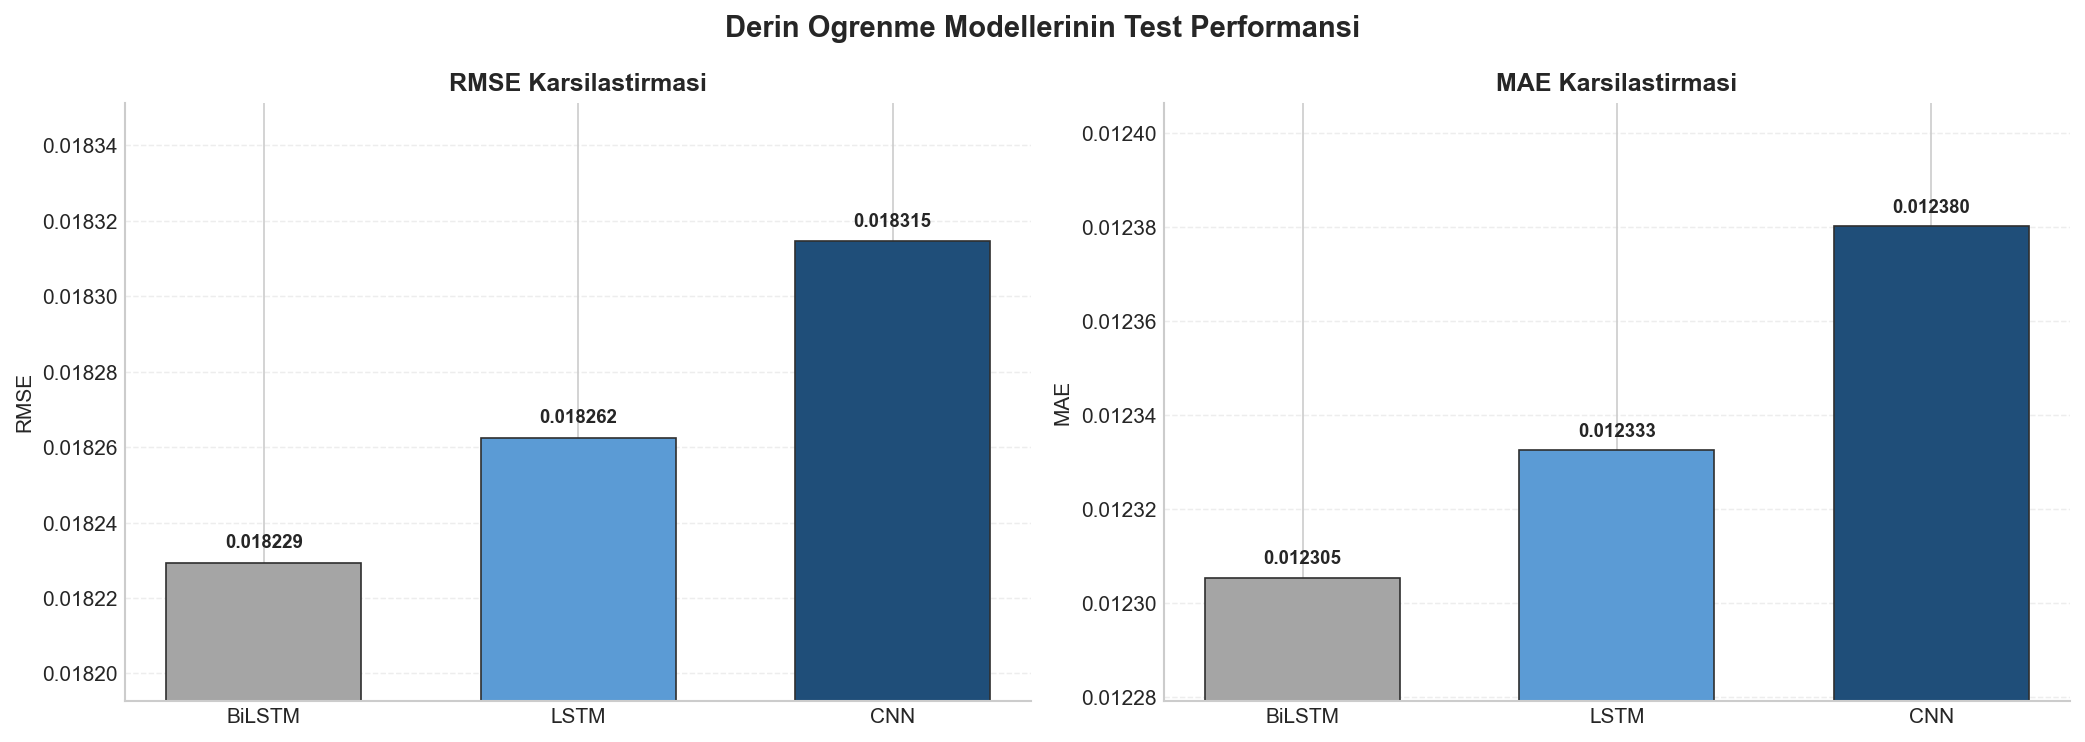

In [48]:
report_colors = {
    'CNN': '#1F4E79',
    'LSTM': '#5B9BD5',
    'BiLSTM': '#A5A5A5'
}
bar_colors = [report_colors[model] for model in results_summary['Model']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
metrics = [('RMSE', 'RMSE Karsilastirmasi'), ('MAE', 'MAE Karsilastirmasi')]

for ax, (metric, title) in zip(axes, metrics):
    values = results_summary[metric].to_numpy()
    bars = ax.bar(
        results_summary['Model'], values, color=bar_colors,
        edgecolor='#2F2F2F', linewidth=0.8, width=0.62
    )
    value_min = values.min()
    value_max = values.max()
    padding = max((value_max - value_min) * 0.35, value_max * 0.002)
    ax.set_ylim(max(0, value_min - padding), value_max + padding)
    ax.set_ylabel(metric)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.35)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, value + padding * 0.08,
            f'{value:.6f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

fig.suptitle('Derin Ogrenme Modellerinin Test Performansi', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()